In [92]:
import os
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd

import time
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_sample_weight
from xgboost import XGBClassifier
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.metrics import roc_curve, roc_auc_score
from sklearn.model_selection import cross_val_score
from sklearn.metrics import precision_recall_curve, f1_score

Loading Dataset

In [55]:
data = pd.read_csv("hospital_readmission_dataset.csv")
data

,patient_id,admission_date,season,age,gender,region,primary_diagnosis,comorbidities_count,length_of_stay,treatment_type,medications_count,followup_visits_last_year,prev_readmissions,insurance_type,discharge_disposition,readmission_risk_score,label
0,P00001,2022-04-14,Spring,66,Male,South,Diabetes,5,6,Interventional,8,6,1,Medicare,Home Health,0.92,1
1,P00002,2021-09-19,Fall,55,Male,South,Diabetes,4,6,Interventional,6,4,3,Private,Home Health,0.88,1
2,P00003,2023-04-12,Spring,69,Female,West,Hypertension,6,8,Medical,9,6,2,Medicare,Skilled Nursing,0.97,1
3,P00004,2023-08-14,Summer,83,Male,South,Stroke,6,11,Medical,11,4,2,Medicare,Skilled Nursing,0.97,1
4,P00005,2021-11-05,Fall,54,Female,North,Stroke,4,10,Medical,6,2,1,Uninsured,Home Health,0.83,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7995,P07996,2022-01-11,Winter,95,Female,East,COPD,6,9,Interventional,11,6,2,Medicare,Skilled Nursing,0.97,1
7996,P07997,2022-05-05,Spring,63,Female,East,Kidney Disease,4,7,Surgical,7,4,1,Medicaid,Home Health,0.94,1
7997,P07998,2021-08-26,Summer,43,Female,East,Diabetes,3,6,Medical,4,2,3,Uninsured,Home Health,0.79,1
7998,P07999,2021-04-20,Spring,86,Male,West,Sepsis,7,12,Interventional,12,5,3,Medicare,Skilled Nursing,0.97,1


In [56]:
data.head()

,patient_id,admission_date,season,age,gender,region,primary_diagnosis,comorbidities_count,length_of_stay,treatment_type,medications_count,followup_visits_last_year,prev_readmissions,insurance_type,discharge_disposition,readmission_risk_score,label
0,P00001,2022-04-14,Spring,66,Male,South,Diabetes,5,6,Interventional,8,6,1,Medicare,Home Health,0.92,1
1,P00002,2021-09-19,Fall,55,Male,South,Diabetes,4,6,Interventional,6,4,3,Private,Home Health,0.88,1
2,P00003,2023-04-12,Spring,69,Female,West,Hypertension,6,8,Medical,9,6,2,Medicare,Skilled Nursing,0.97,1
3,P00004,2023-08-14,Summer,83,Male,South,Stroke,6,11,Medical,11,4,2,Medicare,Skilled Nursing,0.97,1
4,P00005,2021-11-05,Fall,54,Female,North,Stroke,4,10,Medical,6,2,1,Uninsured,Home Health,0.83,1


In [57]:
data.describe()

,age,comorbidities_count,length_of_stay,medications_count,followup_visits_last_year,prev_readmissions,readmission_risk_score,label
count,8000.000000,8000.000000,8000.000000,8000.000000,8000.000000,8000.00000,8000.000000,8000.000000
mean,57.411625,4.318500,7.789125,7.475750,3.638125,1.57250,0.776937,0.772875
std,16.724388,1.358046,1.930252,2.287917,1.630415,0.89196,0.219885,0.419000
min,18.000000,1.000000,3.000000,2.000000,0.000000,0.00000,0.070000,0.000000
25%,46.000000,3.000000,6.000000,6.000000,2.000000,1.00000,0.630000,1.000000
50%,57.000000,4.000000,8.000000,8.000000,4.000000,1.00000,0.860000,1.000000
75%,69.000000,5.000000,9.000000,9.000000,4.000000,2.00000,0.970000,1.000000
max,95.000000,10.000000,15.000000,18.000000,10.000000,5.00000,0.970000,1.000000


In [58]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8000 entries, 0 to 7999
Data columns (total 17 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   patient_id                 8000 non-null   object 
 1   admission_date             8000 non-null   object 
 2   season                     8000 non-null   object 
 3   age                        8000 non-null   int64  
 4   gender                     8000 non-null   object 
 5   region                     8000 non-null   object 
 6   primary_diagnosis          8000 non-null   object 
 7   comorbidities_count        8000 non-null   int64  
 8   length_of_stay             8000 non-null   int64  
 9   treatment_type             8000 non-null   object 
 10  medications_count          8000 non-null   int64  
 11  followup_visits_last_year  8000 non-null   int64  
 12  prev_readmissions          8000 non-null   int64  
 13  insurance_type             8000 non-null   objec

In [59]:
data.columns

Index(['patient_id', 'admission_date', 'season', 'age', 'gender', 'region',
       'primary_diagnosis', 'comorbidities_count', 'length_of_stay',
       'treatment_type', 'medications_count', 'followup_visits_last_year',
       'prev_readmissions', 'insurance_type', 'discharge_disposition',
       'readmission_risk_score', 'label'],
      dtype='object')

### Checking for null values

In [60]:
data.isnull().sum()

patient_id                   0
admission_date               0
season                       0
age                          0
gender                       0
region                       0
primary_diagnosis            0
comorbidities_count          0
length_of_stay               0
treatment_type               0
medications_count            0
followup_visits_last_year    0
prev_readmissions            0
insurance_type               0
discharge_disposition        0
readmission_risk_score       0
label                        0
dtype: int64

### Checking for class imbalance

✓ Both classes present
Class 0: 1,817
Class 1: 6,183
Readmission rate: 340.3%


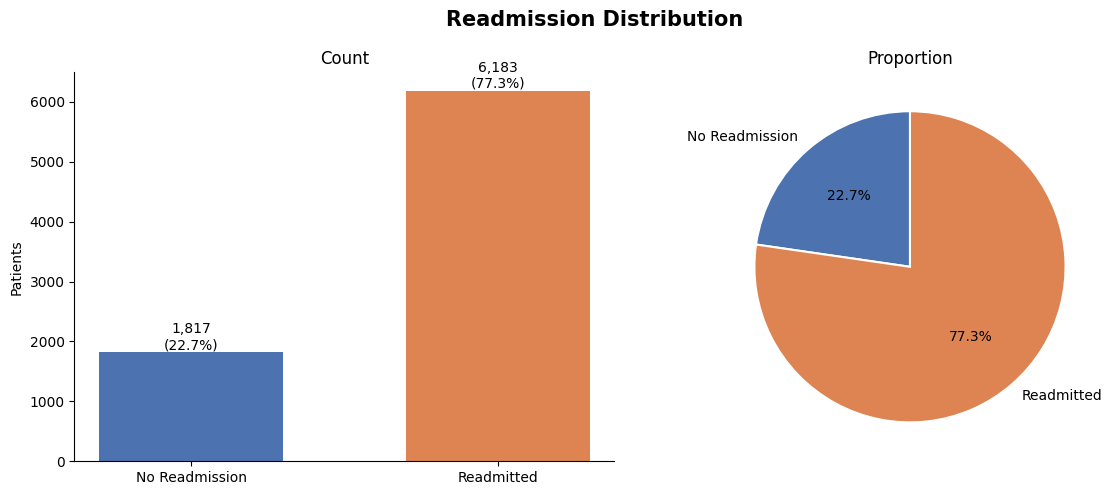

In [61]:
counts = data["label"].value_counts().sort_index()

if len(counts) == 2:
    print("✓ Both classes present")
    print(f"Class 0: {counts[0]:,}")
    print(f"Class 1: {counts[1]:,}")
    print(f"Readmission rate: {(counts[1]/counts[0])*100:.1f}%")

fig, ax = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle("Readmission Distribution", fontsize=15, weight="bold")

colors = ["#4C72B0", "#DD8452"]

bars = ax[0].bar(["No Readmission", "Readmitted"], counts.values, color=colors, width=0.6)

for i, v in enumerate(counts.values):
    ax[0].text(i, v, f"{v:,}\n({v/len(data)*100:.1f}%)",
               ha="center", va="bottom", fontsize=10)

ax[0].set_ylabel("Patients")
ax[0].set_title("Count")
ax[0].spines["top"].set_visible(False)
ax[0].spines["right"].set_visible(False)

ax[1].pie(
    counts.values,
    labels=["No Readmission", "Readmitted"],
    autopct="%1.1f%%",
    startangle=90,
    colors=colors,
    wedgeprops=dict(edgecolor="white", linewidth=1.5)
)

ax[1].set_title("Proportion")

plt.tight_layout()
plt.show()

### Age Distribution

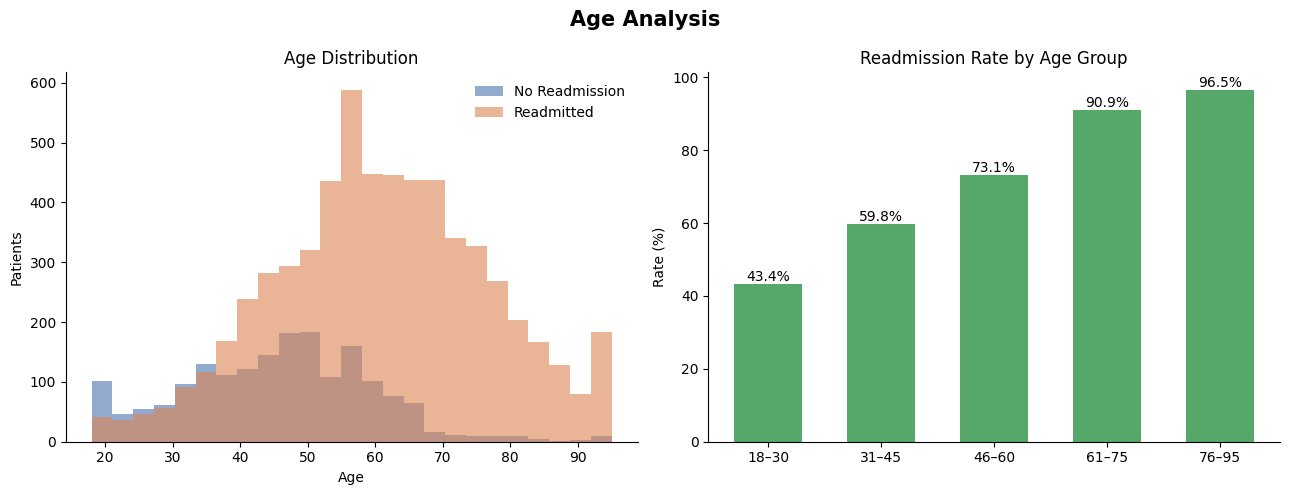

In [62]:
fig, ax = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle("Age Analysis", fontsize=15, weight="bold")

colors = ["#4C72B0", "#DD8452"]  # muted blue & soft orange

for lbl, name, color in [(0, "No Readmission", colors[0]), (1, "Readmitted", colors[1])]:
    subset = data[data["label"] == lbl]["age"]
    ax[0].hist(subset, bins=25, alpha=0.6, label=name, color=color)

ax[0].set_title("Age Distribution")
ax[0].set_xlabel("Age")
ax[0].set_ylabel("Patients")
ax[0].legend(frameon=False)
ax[0].spines["top"].set_visible(False)
ax[0].spines["right"].set_visible(False)

age_bins = pd.cut(
    data["age"],
    bins=[18, 30, 45, 60, 75, 95],
    labels=["18–30", "31–45", "46–60", "61–75", "76–95"]
)

rate = data.groupby(age_bins, observed=True)["label"].mean() * 100

bars = ax[1].bar(rate.index.astype(str), rate.values, color="#55A868", width=0.6)

for i, v in enumerate(rate.values):
    ax[1].text(i, v, f"{v:.1f}%", ha="center", va="bottom", fontsize=10)

ax[1].set_title("Readmission Rate by Age Group")
ax[1].set_ylabel("Rate (%)")
ax[1].spines["top"].set_visible(False)
ax[1].spines["right"].set_visible(False)

plt.tight_layout()
plt.show()

### Exploring Categorical features

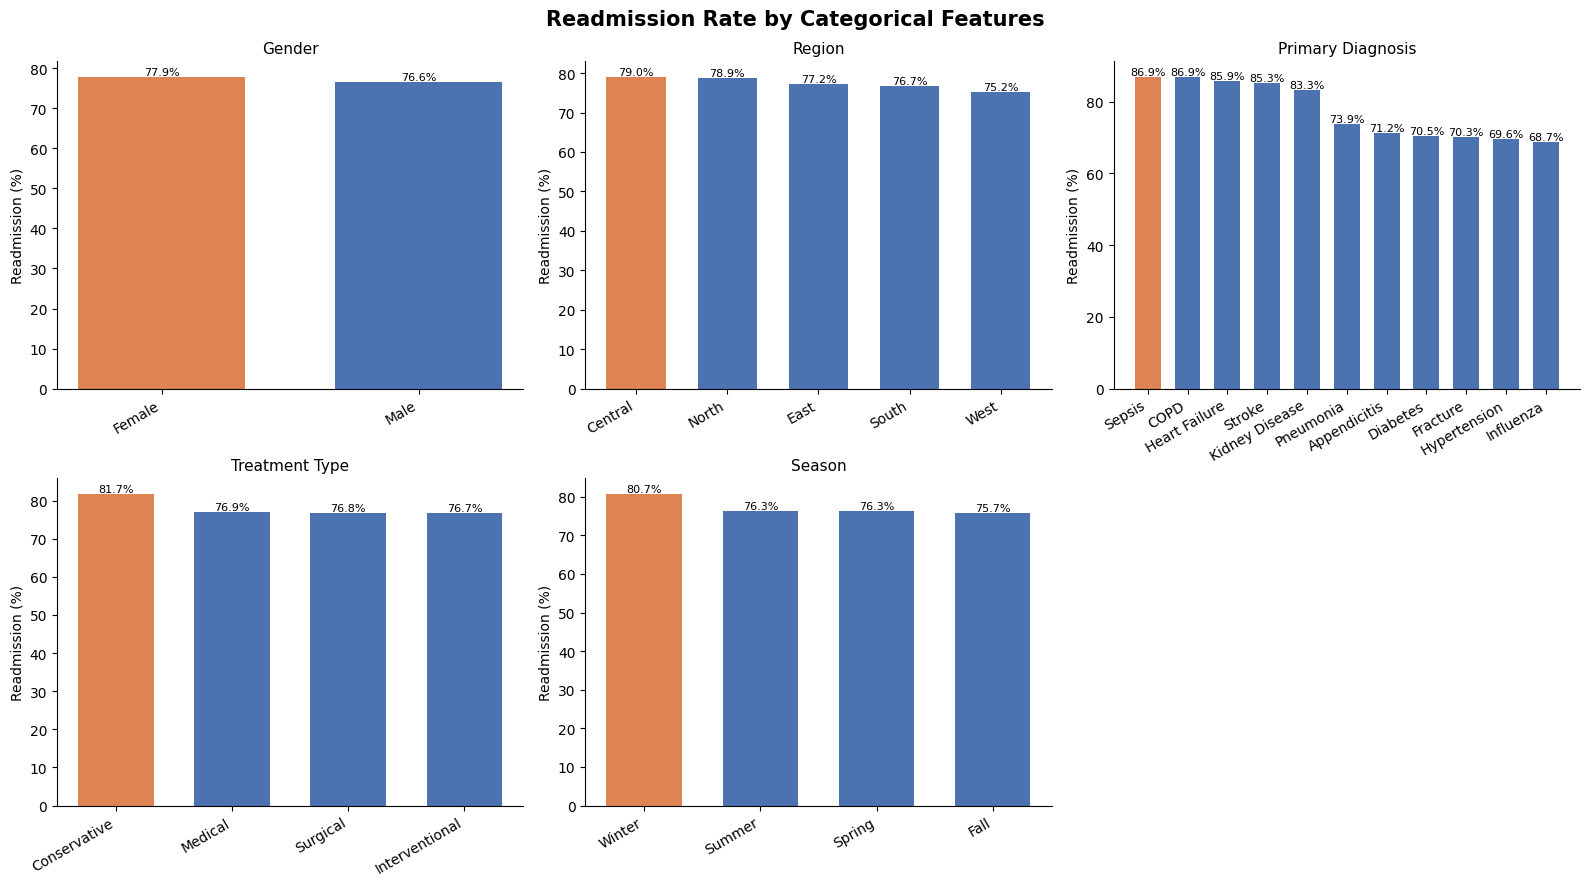

In [63]:
cat_cols = ["gender", "region", "primary_diagnosis", "treatment_type", "season"]

fig, axes = plt.subplots(2, 3, figsize=(16, 9))
fig.suptitle("Readmission Rate by Categorical Features", fontsize=15, weight="bold")
axes = axes.flatten()

main_color = "#4C72B0"
highlight = "#DD8452"

for i, col in enumerate(cat_cols):
    rate = data.groupby(col)["label"].mean().sort_values(ascending=False) * 100

    colors = [main_color] * len(rate)
    if len(colors) > 0:
        colors[0] = highlight

    bars = axes[i].bar(range(len(rate)), rate.values, color=colors, width=0.65)

    axes[i].set_xticks(range(len(rate)))
    axes[i].set_xticklabels(rate.index, rotation=30, ha="right")
    axes[i].set_title(col.replace("_", " ").title(), fontsize=11)
    axes[i].set_ylabel("Readmission (%)")

    axes[i].spines["top"].set_visible(False)
    axes[i].spines["right"].set_visible(False)

    for j, v in enumerate(rate.values):
        axes[i].text(j, v, f"{v:.1f}%", ha="center", va="bottom", fontsize=8)

axes[-1].set_visible(False)

plt.tight_layout()
plt.show()

### Numerical Features

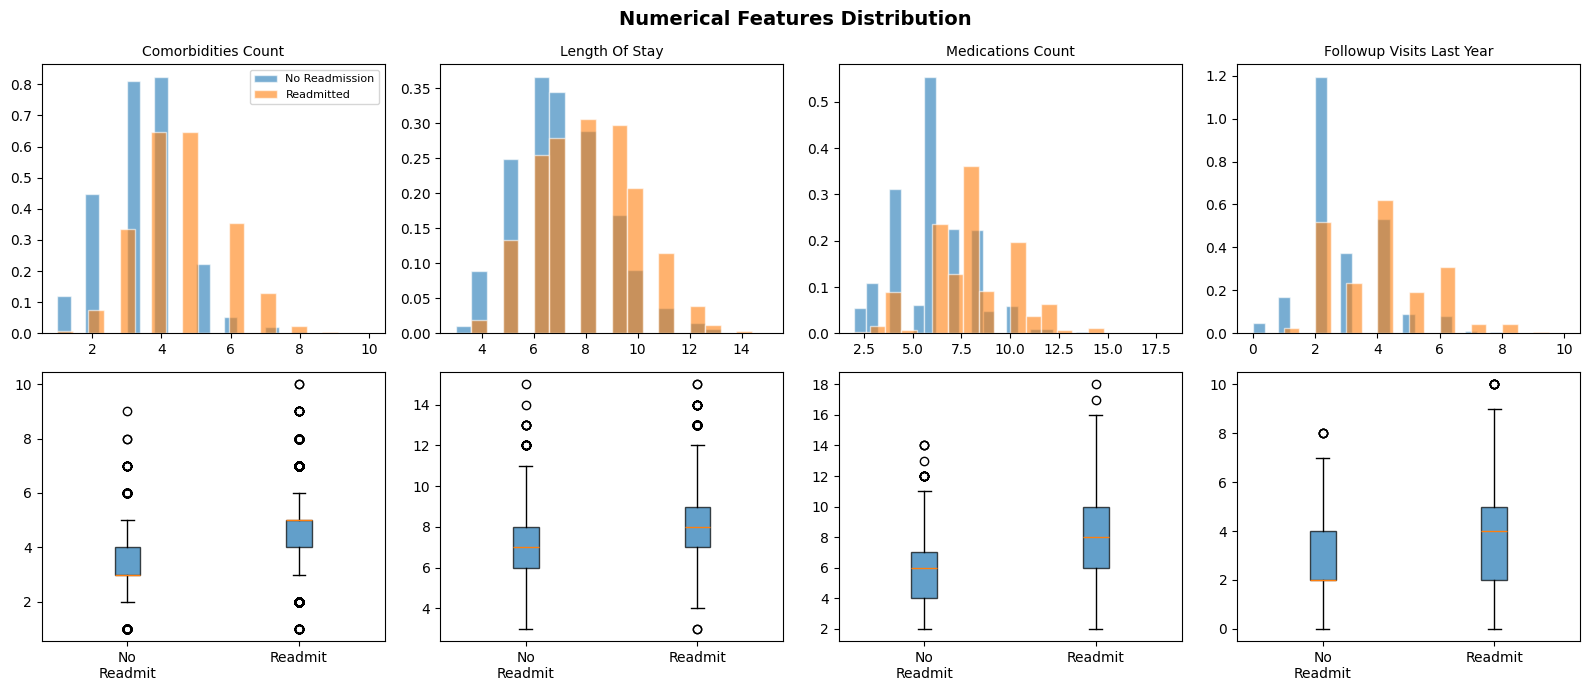

In [64]:
num_cols = ["comorbidities_count", "length_of_stay",
            "medications_count", "followup_visits_last_year"]

fig, axes = plt.subplots(2, 4, figsize=(16, 7))
fig.suptitle("Numerical Features Distribution", fontsize=14, fontweight="bold")

for i, col in enumerate(num_cols):

    # Histogram
    for lbl, name in [(0, "No Readmission"), (1, "Readmitted")]:
        subset = data[data["label"] == lbl][col]
        axes[0, i].hist(subset, bins=20, alpha=0.6,
                        label=name, density=True, edgecolor="white")

    axes[0, i].set_title(col.replace("_", " ").title(), fontsize=10)

    if i == 0:
        axes[0, i].legend(fontsize=8)

    # Boxplot
    data_0 = data[data["label"] == 0][col]
    data_1 = data[data["label"] == 1][col]

    bp = axes[1, i].boxplot([data_0, data_1],
                            patch_artist=True,
                            labels=["No\nReadmit", "Readmit"])

    for patch in bp["boxes"]:
        patch.set_alpha(0.7)

plt.tight_layout()
plt.show()


### Computing correlation matrix

Computing correlation matrix


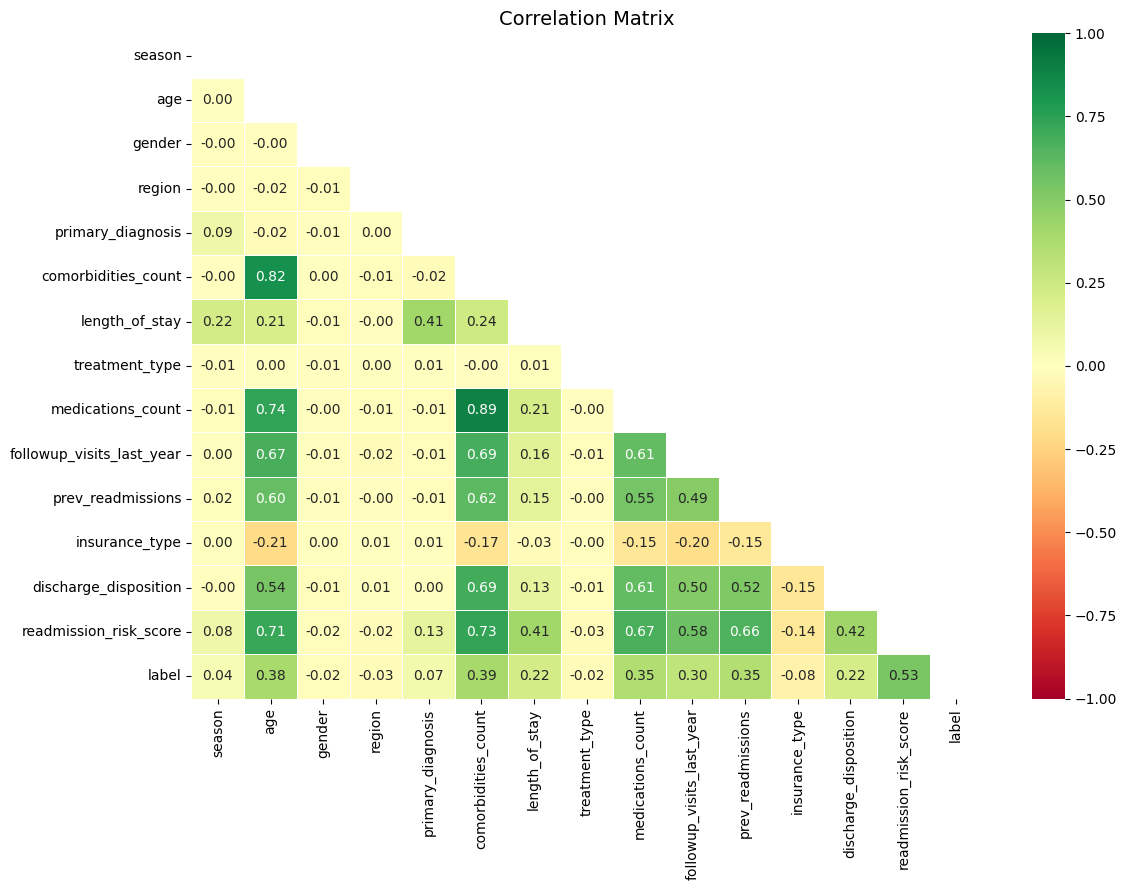

In [65]:
%matplotlib inline

print("Computing correlation matrix")

data_enc = data.copy()

cols = [
    "gender", "region", "primary_diagnosis",
    "treatment_type", "season",
    "insurance_type", "discharge_disposition"
]

# Encode using pandas (no sklearn needed)
for col in cols:
    data_enc[col] = data_enc[col].astype("category").cat.codes

data_enc = data_enc.drop(columns=["patient_id", "admission_date"], errors="ignore")

corr = data_enc.corr()

plt.figure(figsize=(12, 9))

mask = np.triu(np.ones_like(corr, dtype=bool))

sns.heatmap(
    corr,
    mask=mask,
    annot=True,
    fmt=".2f",
    cmap="RdYlGn",
    vmin=-1,
    vmax=1,
    linewidths=0.5,
    linecolor="white"
)

plt.title("Correlation Matrix", fontsize=14)
plt.tight_layout()
plt.show()

### Temporal Drift

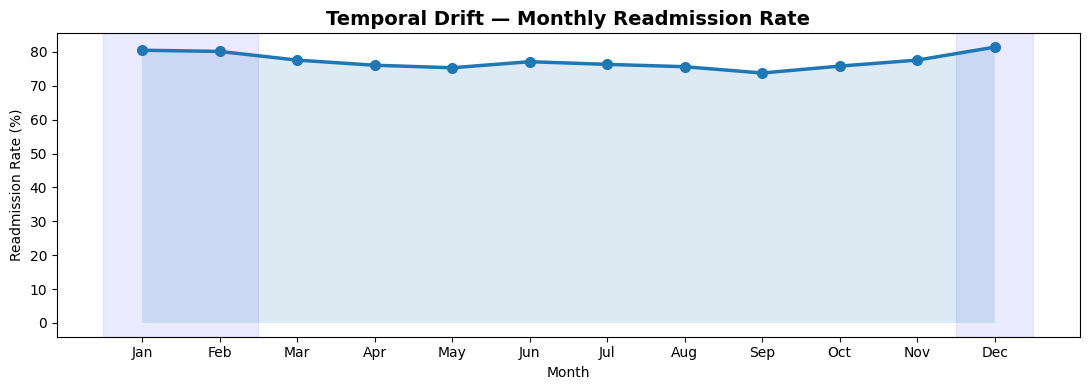

In [66]:
data["admission_date"] = pd.to_datetime(data["admission_date"])
data["month"] = data["admission_date"].dt.month
monthly = data.groupby("month")["label"].mean() * 100

fig, ax = plt.subplots(figsize=(11, 4))
ax.plot(monthly.index, monthly.values, linewidth=2.5, marker="o", markersize=7)
ax.fill_between(monthly.index, monthly.values, alpha=0.15)
ax.set_xticks(range(1, 13))
ax.set_xticklabels(["Jan","Feb","Mar","Apr","May","Jun",
                    "Jul","Aug","Sep","Oct","Nov","Dec"])
ax.set_title("Temporal Drift — Monthly Readmission Rate",
             fontsize=14, fontweight="bold")
ax.set_ylabel("Readmission Rate (%)")
ax.set_xlabel("Month")
# Shade winter
ax.axvspan(0.5, 2.5,  alpha=0.08, color="blue", label="Winter")
ax.axvspan(11.5, 12.5, alpha=0.08, color="blue")
plt.tight_layout()
plt.show()


### Feature Engineering

In [67]:
data_ml = data_enc.copy()

data_ml["age_x_comorbidities"]   = data_ml["age"] * data_ml["comorbidities_count"]
data_ml["los_x_medications"]     = data_ml["length_of_stay"] * data_ml["medications_count"]
data_ml["high_risk_age"]         = (data_ml["age"] >= 65).astype(int)
data_ml["complex_case"]          = ((data_ml["comorbidities_count"] >= 4) &
                                    (data_ml["medications_count"] >= 6)).astype(int)
data_ml["frequent_visitor"]      = (data_ml["followup_visits_last_year"] >= 4).astype(int)
data_ml["short_stay"]            = (data_ml["length_of_stay"] <= 2).astype(int)

data_ml["risk_score_manual"]     = (
    data_ml["age"] / 95 * 0.3 +
    data_ml["comorbidities_count"] / 10 * 0.4 +
    data_ml["prev_readmissions"] / 5 * 0.3
)
data_ml["poly_age_como"]         = data_ml["age"] ** 2 + data_ml["comorbidities_count"] ** 2
data_ml["short_stay_highrisk"]   = data_ml["short_stay"] * data_ml["comorbidities_count"]
data_ml["prev_x_como"]           = data_ml["prev_readmissions"] * data_ml["comorbidities_count"]
data_ml["age_x_prev"]            = data_ml["age"] * data_ml["prev_readmissions"]
data_ml["meds_x_visits"]         = data_ml["medications_count"] * data_ml["followup_visits_last_year"]

drop_cols = ["readmission_risk_score", "month"]
X = data_ml.drop(columns=["label"] + drop_cols, errors="ignore")
y = data_ml["label"]

print(f"  Features after engineering: {X.shape[1]}")
print(f"  Feature list: {list(X.columns)}")

  Features after engineering: 25
  Feature list: ['season', 'age', 'gender', 'region', 'primary_diagnosis', 'comorbidities_count', 'length_of_stay', 'treatment_type', 'medications_count', 'followup_visits_last_year', 'prev_readmissions', 'insurance_type', 'discharge_disposition', 'age_x_comorbidities', 'los_x_medications', 'high_risk_age', 'complex_case', 'frequent_visitor', 'short_stay', 'risk_score_manual', 'poly_age_como', 'short_stay_highrisk', 'prev_x_como', 'age_x_prev', 'meds_x_visits']


In [68]:
data_ml.head()

,season,age,gender,region,primary_diagnosis,comorbidities_count,length_of_stay,treatment_type,medications_count,followup_visits_last_year,...,high_risk_age,complex_case,frequent_visitor,short_stay,risk_score_manual,poly_age_como,short_stay_highrisk,prev_x_como,age_x_prev,meds_x_visits
0,1,66,1,3,2,5,6,1,8,6,...,1,1,1,0,0.468421,4381,0,5,66,48
1,0,55,1,3,2,4,6,1,6,4,...,0,1,1,0,0.513684,3041,0,12,165,24
2,1,69,0,4,5,6,8,2,9,6,...,1,1,1,0,0.577895,4797,0,12,138,54
3,2,83,1,3,10,6,11,2,11,4,...,1,1,1,0,0.622105,6925,0,12,166,44
4,0,54,0,2,10,4,10,2,6,2,...,0,1,0,0,0.390526,2932,0,4,54,12


### Model Training

In [ ]:

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

weights = compute_sample_weight("balanced", y_train)

models = {}

### XGBost Model

In [70]:


print("Starting XGBoost training...")

xgb_model = XGBClassifier(
    n_estimators=200,
    max_depth=5,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    eval_metric="logloss"
)

xgb_model.fit(X_train, y_train, sample_weight=weights)

print("XGBoost training complete ")

models["xgboost"] = xgb_model

Starting XGBoost training...
XGBoost training complete 


### Random Forest Model

In [71]:


print("Starting Random Forest training...")

rf_model = RandomForestClassifier(
    n_estimators=200,
    max_depth=8,
    random_state=42
)

rf_model.fit(X_train, y_train, sample_weight=weights)

print("Random Forest training complete")

models["random_forest"] = rf_model

Starting Random Forest training...
Random Forest training complete


### Logistic Regression Model

In [72]:
print("Training Logistic Regression...")
start = time.time()

lr_model = LogisticRegression(max_iter=1000)

lr_model.fit(X_train, y_train, sample_weight=weights)

end = time.time()
print(f"Logistic Regression done in {end - start:.2f} seconds")

models["logistic_regression"] = lr_model

Training Logistic Regression...
Logistic Regression done in 0.47 seconds


### Gradient Boosting Model

In [73]:

print("Training Gradient Boosting...")
start = time.time()

gb_model = GradientBoostingClassifier(
    n_estimators=150,
    learning_rate=0.05,
    max_depth=3,
    random_state=42
)

gb_model.fit(X_train, y_train)

end = time.time()
print(f"Gradient Boosting done in {end - start:.2f} seconds")

models["gradient_boosting"] = gb_model

Training Gradient Boosting...
Gradient Boosting done in 1.22 seconds


### Model Evaluation

Evaluating xgboost...
Evaluating random_forest...
Evaluating logistic_regression...
Evaluating gradient_boosting...

=== Model Performance ===
                 model  accuracy  precision    recall  f1_score
3    gradient_boosting  0.811875   0.838150  0.937753  0.885158
1        random_forest  0.747500   0.898565  0.759095  0.822962
0              xgboost  0.751250   0.915758  0.746968  0.822796
2  logistic_regression  0.718750   0.911181  0.704931  0.794895


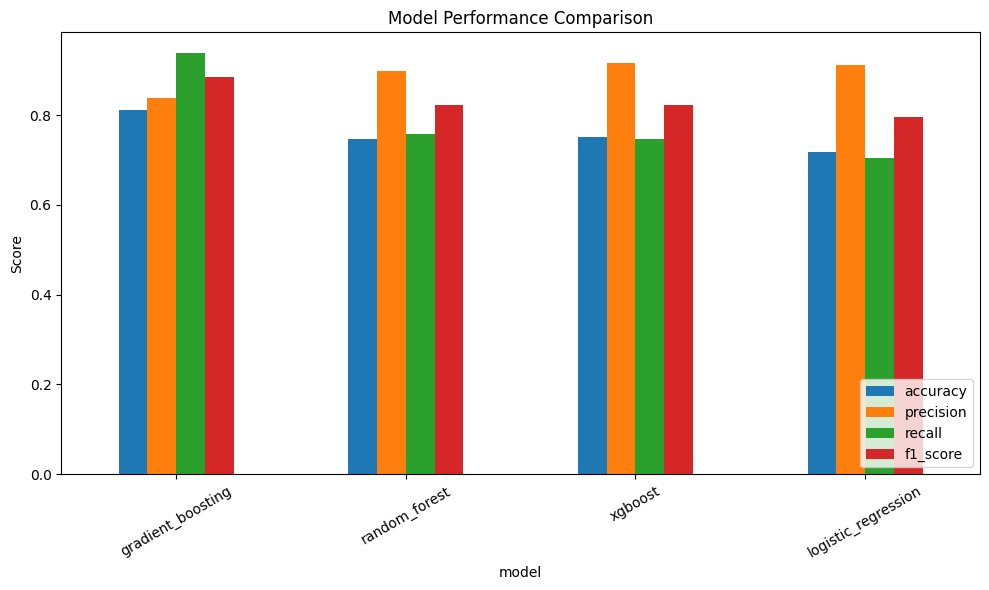


Best model: gradient_boosting
Best F1 score: 0.8852


In [ ]:

results = []

# ---- Evaluate all models ----
for name, model in models.items():
    print(f"Evaluating {name}...")

    y_pred = model.predict(X_test)

    results.append({
        "model": name,
        "accuracy": accuracy_score(y_test, y_pred),
        "precision": precision_score(y_test, y_pred, zero_division=0),
        "recall": recall_score(y_test, y_pred, zero_division=0),
        "f1_score": f1_score(y_test, y_pred, zero_division=0)
    })

# ---- Create results dataframe ----
results_df = pd.DataFrame(results).sort_values(by="f1_score", ascending=False)

print("\n=== Model Performance ===")
print(results_df)

# ---- Plot comparison chart ----
results_plot = results_df.set_index("model")

results_plot.plot(kind="bar", figsize=(10, 6))

plt.title("Model Performance Comparison")
plt.ylabel("Score")
plt.xticks(rotation=30)
plt.legend(loc="lower right")
plt.tight_layout()
plt.show()

# ---- Select best model ----
best_model_name = results_df.iloc[0]["model"]
best_score = results_df.iloc[0]["f1_score"]

print(f"\nBest model: {best_model_name}")
print(f"Best F1 score: {best_score:.4f}")

# ---- Get best model object ----
best_model = models[best_model_name]


Evaluating best model: gradient_boosting

Classification Report:
              precision    recall  f1-score   support

           0       0.64      0.38      0.48       363
           1       0.84      0.94      0.89      1237

    accuracy                           0.81      1600
   macro avg       0.74      0.66      0.68      1600
weighted avg       0.79      0.81      0.79      1600



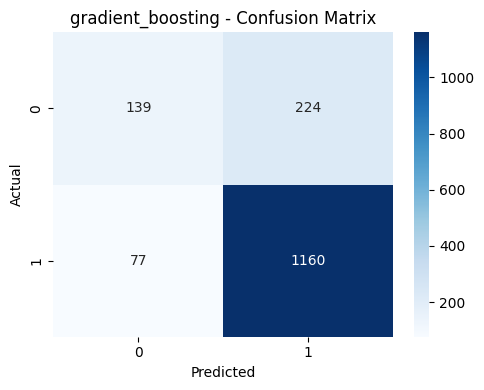

In [83]:

print(f"\nEvaluating best model: {best_model_name}")

# predictions
y_pred = best_model.predict(X_test)

# ---- Classification Report ----
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

# ---- Confusion Matrix ----
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")

plt.title(f"{best_model_name} - Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.tight_layout()
plt.show()

### ROC curve

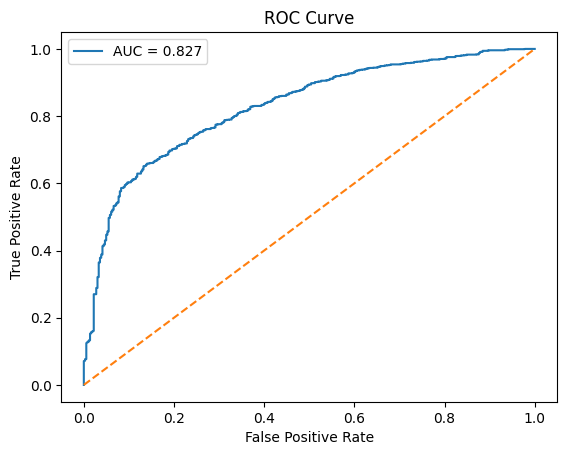

In [87]:

y_prob = best_model.predict_proba(X_test)[:, 1]

fpr, tpr, _ = roc_curve(y_test, y_prob)
auc = roc_auc_score(y_test, y_prob)

plt.figure()
plt.plot(fpr, tpr, label=f"AUC = {auc:.3f}")
plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

### Feature Importance

              feature  importance
19  risk_score_manual    0.335372
23         age_x_prev    0.222036
22        prev_x_como    0.115868
14  los_x_medications    0.076810
6      length_of_stay    0.061125
4   primary_diagnosis    0.049143
10  prev_readmissions    0.029784
11     insurance_type    0.020639
8   medications_count    0.019996
20      poly_age_como    0.012938


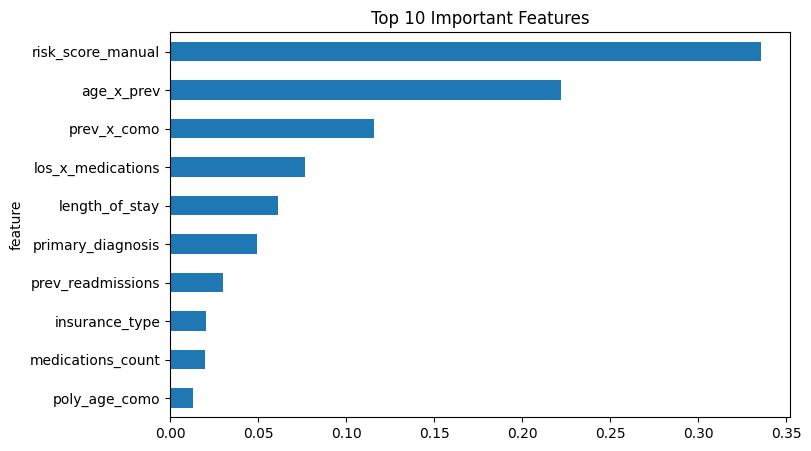

In [88]:

importance = best_model.feature_importances_
features = X.columns

feat_imp = pd.DataFrame({
    "feature": features,
    "importance": importance
}).sort_values(by="importance", ascending=False)

print(feat_imp.head(10))

feat_imp.head(10).plot(
    kind="barh",
    x="feature",
    y="importance",
    figsize=(8, 5),
    legend=False
)

plt.gca().invert_yaxis()
plt.title("Top 10 Important Features")
plt.show()

### Cross Validation

In [97]:
from sklearn.model_selection import cross_val_score

cross_val_score(best_model, X_train, y_train, cv=5, scoring="f1")
print("CV F1 score:", scores.mean())

CV F1 score: 0.883823248624285


### Thresholds


Running Cross-Validation...
F1 scores (each fold): [0.88404133 0.88405797 0.89304813 0.88103383 0.87693498]
Mean F1 score: 0.8838


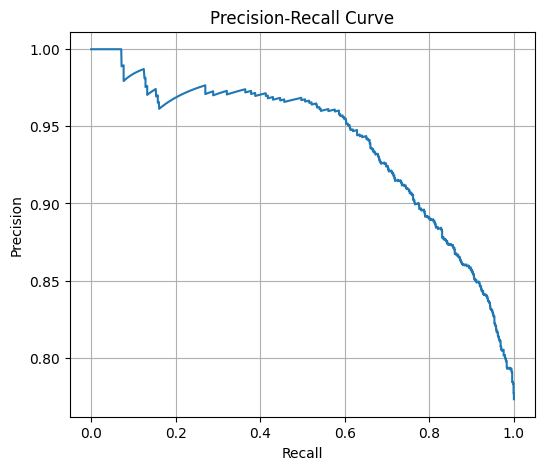


Best threshold: 0.488
Best F1 score: 0.8861


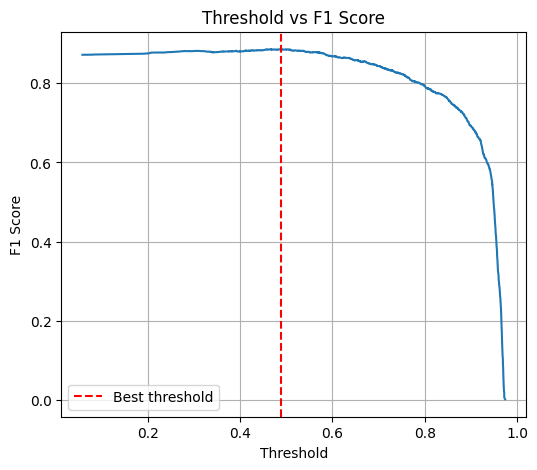


Sample predictions with tuned threshold:
[1 1 1 1 1 1 1 1 1 1]


In [101]:

print("\nRunning Cross-Validation...")

cross_val_score(best_model, X_train, y_train, cv=5, scoring="f1")

print(f"F1 scores (each fold): {cv_scores}")
print(f"Mean F1 score: {cv_scores.mean():.4f}")

y_prob = best_model.predict_proba(X_test)[:, 1]


precision, recall, thresholds = precision_recall_curve(y_test, y_prob)

plt.figure(figsize=(6, 5))
plt.plot(recall, precision)
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve")
plt.grid()
plt.show()


f1_scores = []

for t in thresholds:
    y_pred_t = (y_prob >= t).astype(int)
    f1_scores.append(f1_score(y_test, y_pred_t))

f1_scores = np.array(f1_scores)

# best threshold
best_idx = np.argmax(f1_scores)
best_threshold = thresholds[best_idx]
best_f1 = f1_scores[best_idx]

print(f"\nBest threshold: {best_threshold:.3f}")
print(f"Best F1 score: {best_f1:.4f}")


plt.figure(figsize=(6, 5))
plt.plot(thresholds, f1_scores)
plt.axvline(best_threshold, color="red", linestyle="--", label="Best threshold")
plt.xlabel("Threshold")
plt.ylabel("F1 Score")
plt.title("Threshold vs F1 Score")
plt.legend()
plt.grid()
plt.show()

y_pred_best = (y_prob >= best_threshold).astype(int)

print("\nSample predictions with tuned threshold:")
print(y_pred_best[:10])

### Reevaluating Model with threshold


Evaluation with tuned threshold (0.49)

Classification Report:
              precision    recall  f1-score   support

           0       0.66      0.37      0.47       363
           1       0.84      0.94      0.89      1237

    accuracy                           0.81      1600
   macro avg       0.75      0.65      0.68      1600
weighted avg       0.79      0.81      0.79      1600



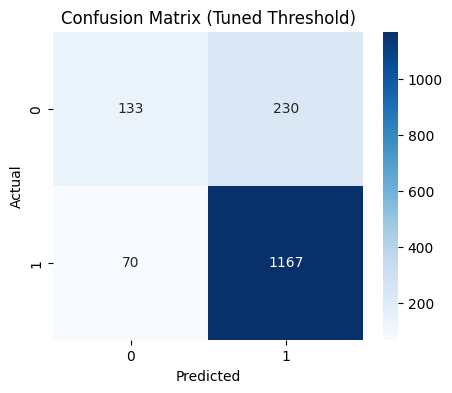

In [99]:
from sklearn.metrics import classification_report, confusion_matrix

print(f"\nEvaluation with tuned threshold ({best_threshold:.2f})")

print("\nClassification Report:")
print(classification_report(y_test, y_pred_best))

cm = confusion_matrix(y_test, y_pred_best)

plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")

plt.title("Confusion Matrix (Tuned Threshold)")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

### Before vs after Threshold


=== Default Threshold (0.5) ===
              precision    recall  f1-score   support

           0       0.64      0.38      0.48       363
           1       0.84      0.94      0.89      1237

    accuracy                           0.81      1600
   macro avg       0.74      0.66      0.68      1600
weighted avg       0.79      0.81      0.79      1600



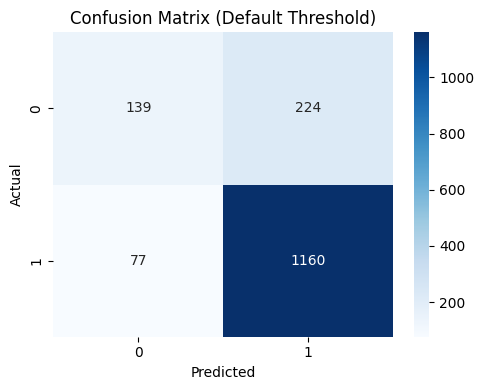


=== Tuned Threshold ===
              precision    recall  f1-score   support

           0       0.66      0.37      0.47       363
           1       0.84      0.94      0.89      1237

    accuracy                           0.81      1600
   macro avg       0.75      0.65      0.68      1600
weighted avg       0.79      0.81      0.79      1600



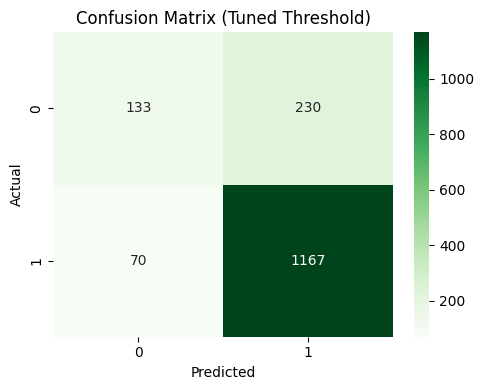

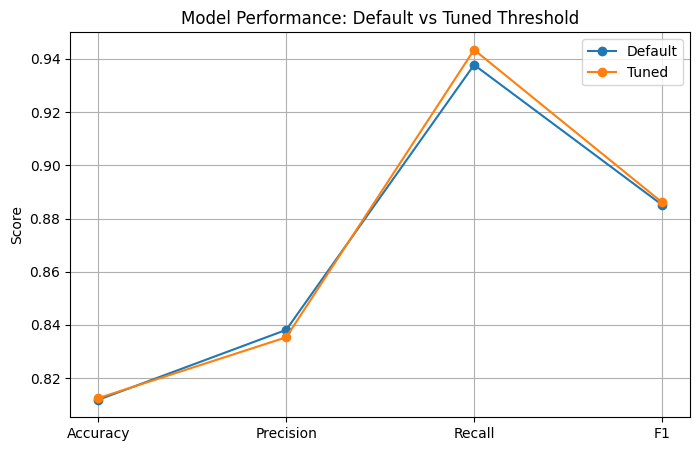

In [ ]:

print("\n=== Default Threshold (0.5) ===")
y_pred_default = best_model.predict(X_test)
print(classification_report(y_test, y_pred_default))

cm_default = confusion_matrix(y_test, y_pred_default)

plt.figure(figsize=(5, 4))
sns.heatmap(cm_default, annot=True, fmt="d", cmap="Blues")
plt.title("Confusion Matrix (Default Threshold)")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()
plt.show()



print("\n=== Tuned Threshold ===")
print(classification_report(y_test, y_pred_best))

cm_tuned = confusion_matrix(y_test, y_pred_best)

plt.figure(figsize=(5, 4))
sns.heatmap(cm_tuned, annot=True, fmt="d", cmap="Greens")
plt.title("Confusion Matrix (Tuned Threshold)")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()
plt.show()



from sklearn.metrics import precision_score, recall_score, f1_score, accuracy_score

metrics = {
    "Default": [
        accuracy_score(y_test, y_pred_default),
        precision_score(y_test, y_pred_default, zero_division=0),
        recall_score(y_test, y_pred_default, zero_division=0),
        f1_score(y_test, y_pred_default, zero_division=0)
    ],
    "Tuned": [
        accuracy_score(y_test, y_pred_best),
        precision_score(y_test, y_pred_best, zero_division=0),
        recall_score(y_test, y_pred_best, zero_division=0),
        f1_score(y_test, y_pred_best, zero_division=0)
    ]
}

labels = ["Accuracy", "Precision", "Recall", "F1"]

x = range(len(labels))

plt.figure(figsize=(8, 5))
plt.plot(x, metrics["Default"], marker="o", label="Default")
plt.plot(x, metrics["Tuned"], marker="o", label="Tuned")

plt.xticks(x, labels)
plt.title("Model Performance: Default vs Tuned Threshold")
plt.ylabel("Score")
plt.legend()
plt.grid()
plt.show()